# Exhibit: Is Professional Forecasting Worth It?

*Workshop 2 exhibit — **Structural Change and Expectations in Macroeconomics and Finance** (University of Copenhagen, Autumn 2026).*

## 1. The relation

Professional forecasters bring models, data, and judgment to predicting inflation. How much is all that worth, compared with the simplest possible rule — a **naive forecast** that says *next year's inflation will equal the past year's*?

This benchmark question has a distinguished history: Atkeson and Ohanian (2001) famously showed that for US inflation after 1984, sophisticated Phillips-curve forecasts could not beat a naive random-walk rule. The object of interest here is a *relative accuracy* relation:

$$\text{RMSE}^{\text{SPF}} \;\text{vs.}\; \text{RMSE}^{\text{naive}},$$

the root-mean-squared error of the professional (SPF) forecast against that of the naive rule. A ratio below 1 means the professionals add value.

**Data:** the same dataset as Workshop 1's notebook — SPF mean forecasts of one-year-ahead GDP-deflator inflation and first-release actuals, 1970–2024. The naive forecast of the next four quarters is inflation over the *past* four quarters (`pi_lag`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, RED, TEAL, GREY = "#006BA2", "#DB444B", "#3EBCD2", "#758D99"
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.35,
    "axes.titlelocation": "left", "axes.titlesize": 12, "font.size": 11,
})

def load(name):
    try:
        df = pd.read_csv(f"../data/{name}", index_col="quarter")
    except FileNotFoundError:
        base = "https://raw.githubusercontent.com/mortentabor/structural-change-seminar/main/data/"
        df = pd.read_csv(base + name, index_col="quarter")
    df.index = pd.PeriodIndex(df.index, freq="Q")
    return df

fe = load("forecast_errors.csv").dropna(subset=["error_avg", "pi_avg", "pi_lag"]).copy()
fe["e_spf"] = fe["error_avg"]                    # SPF forecast error (from Workshop 1)
fe["e_naive"] = fe["pi_avg"] - fe["pi_lag"]      # naive rule: next year = past year
fe.tail(3)

,F_avg,pi_avg,error_avg,revision_avg,pi_lag,error_avg_h1,error_avg_h2,error_avg_h3,revision_avg_h1,revision_avg_h2,revision_avg_h3,e_spf,e_naive
quarter,,,,,,,,,,,,,
2023Q4,2.141275,2.360500,0.219225,-0.523275,1.4806,1.0144,0.57990,0.261633,-0.6273,-0.56745,-0.531367,0.219225,0.879900
2024Q1,2.558100,2.515650,-0.042450,0.403400,3.1213,-0.6106,-0.67340,-0.491333,0.7560,0.55865,0.445500,-0.042450,-0.605650
2024Q2,2.378950,2.439775,0.060825,-0.011950,2.2829,-0.5577,-0.36445,0.225800,-0.1785,-0.06725,-0.078867,0.060825,0.156875


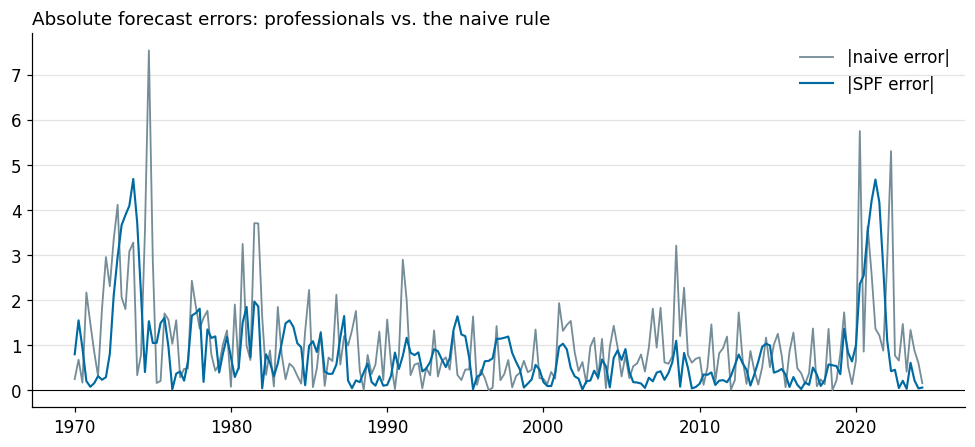

In [2]:
fig, ax = plt.subplots(figsize=(9, 4.2))
x = fe.index.to_timestamp()
ax.axhline(0, color="black", lw=0.7)
ax.plot(x, fe["e_naive"].abs(), color=GREY, lw=1.2, label="|naive error|")
ax.plot(x, fe["e_spf"].abs(), color=BLUE, lw=1.4, label="|SPF error|")
ax.set_title("Absolute forecast errors: professionals vs. the naive rule")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 2. The full-sample comparison

In [3]:
def rmse(x):
    return float(np.sqrt(np.mean(np.asarray(x) ** 2)))

r_spf, r_naive = rmse(fe["e_spf"]), rmse(fe["e_naive"])
print(f"Sample: {fe.index.min()}–{fe.index.max()}  (n = {len(fe)})")
print(f"RMSE, SPF:   {r_spf:.3f}")
print(f"RMSE, naive: {r_naive:.3f}")
print(f"Ratio SPF/naive: {r_spf / r_naive:.2f}")

Sample: 1970Q1–2024Q2  (n = 218)
RMSE, SPF:   1.183
RMSE, naive: 1.474
Ratio SPF/naive: 0.80


Over the full sample the professionals win comfortably: their errors are about 20% smaller than the naive rule's. Professional forecasting pays.

**But is that advantage a stable feature — or an average over very different periods?**

## 3. Is it stable? Your turn first

Compute the comparison by subperiod — then **change the splits** (edit the dictionary, rerun). When do the professionals earn their keep, and when don't they?

In [4]:
SUBSAMPLES = {
    "1970s":            ("1970Q2", "1979Q4"),
    "Great Moderation": ("1980Q1", "2019Q4"),
    "Post-2020":        ("2020Q1", "2024Q2"),
}

rows = []
for name, (start, end) in SUBSAMPLES.items():
    d = fe.loc[start:end]
    rows.append({"sample": name, "RMSE SPF": rmse(d["e_spf"]), "RMSE naive": rmse(d["e_naive"]),
                 "ratio": rmse(d["e_spf"]) / rmse(d["e_naive"]), "n": len(d)})
pd.DataFrame(rows).round(3)

,sample,RMSE SPF,RMSE naive,ratio,n
0,1970s,1.826,2.207,0.827,39
1,Great Moderation,0.719,1.069,0.673,160
2,Post-2020,2.256,2.368,0.953,18


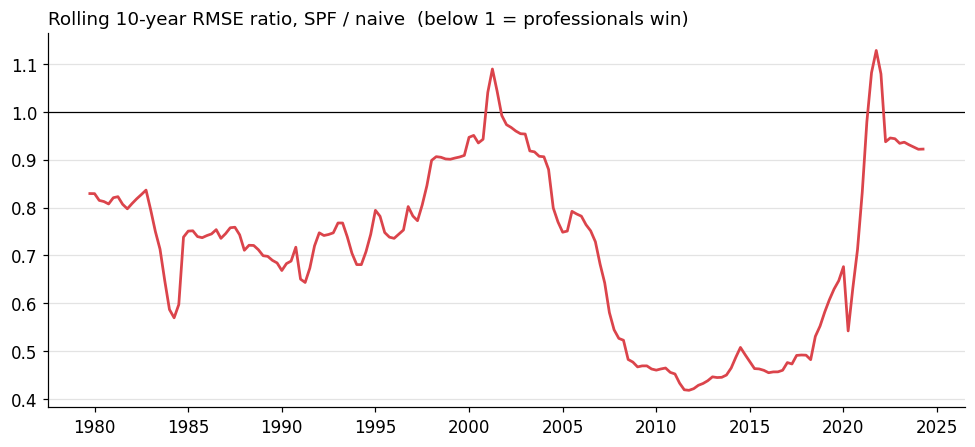

In [5]:
# The same story continuously: rolling 10-year RMSE ratio
roll_spf = fe["e_spf"].pow(2).rolling(40).mean().pow(0.5)
roll_naive = fe["e_naive"].pow(2).rolling(40).mean().pow(0.5)
ratio = roll_spf / roll_naive

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axhline(1.0, color="black", lw=0.8)
ax.plot(fe.index.to_timestamp(), ratio, color=RED, lw=1.8)
ax.set_title("Rolling 10-year RMSE ratio, SPF / naive  (below 1 = professionals win)")
plt.tight_layout()
plt.show()

### What you should see

The professionals' advantage is **not stable**:

- During the **Great Moderation** their errors were a third smaller than the naive rule's (ratio ≈ 0.67) — at its best, around 2011, the rolling ratio touches **0.42**.
- In the turbulent periods the advantage shrinks toward nothing: ratio ≈ 0.83 in the 1970s, ≈ **0.95 post-2020**. Around the 2021 inflation surge the rolling ratio briefly rises **above 1 — the naive rule beat the professionals**.

Read that twice, because it is uncomfortable: professional forecasting adds the *most* value in calm times, when forecasts are easy — and the *least* value exactly when the economy shifts and forecasts matter most.

(A formal test on the loss differential finds no significant mean breaks over the full sample — the loss series is very noisy. Rolling comparisons and subsamples are the sharper lens here; the formal toolbox comes in Workshop 3.)

### Probe the claims yourself

Two claims above deserve stress-testing: the professionals' advantage peaks around 2011 (ratio ≈ 0.42) and vanishes around 2021 (ratio above 1). Both come from a **40-quarter rolling window** — a choice, not a law of nature. Change it in the rolling cell above and rerun:

```python
roll_spf = fe["e_spf"].pow(2).rolling(20).mean().pow(0.5)     # try 20, then 60
roll_naive = fe["e_naive"].pow(2).rolling(20).mean().pow(0.5)
```

Is the 2021 crossing above 1 robust to the window choice? And move your own `SUBSAMPLES` splits: how early can you start “post-2020” and still see the advantage collapse? (A formal test for equal forecast accuracy — and what instability does to it — is Workshop 3 material.)

## 4. What could a paper deliver?

You have now seen that the relation is not stable. **That, by itself, is not yet a research question.** "Is X stable? — No" is a finding, not a paper. The interesting paper starts with what you build *on top of* the finding. Four types of questions you can build:

1. **Timing / episodes** — is the collapse of the forecasters' advantage concentrated in identifiable episodes (the oil shocks, 2008, COVID)? Is it the same episodes where *their errors* became predictable (Workshop 1)?
2. **Source / mechanism** — *why* does the advantage vanish in turbulence? Do professionals and the naive rule fail in the same direction (both surprised) or differently?
3. **Interpretation / inference** — what does an unstable advantage mean for how we *evaluate* forecasters? Is a full-sample RMSE comparison the right yardstick if the ranking flips across regimes?
4. **Consequences / practice** — a central bank buys forecasts precisely for the turbulent times. If that is when the value evaporates, what should it do instead — and did central banks' own forecasts (ECB, Fed) show the same pattern in 2021–22?

**The "This paper…" exercise.** A research question is specific when you can state what the paper *delivers*. Compare (on a relation that is *not* one of today's exhibits):

> *Weak:* "This paper examines whether Okun's law is stable."
>
> *Strong:* "This paper shows that Okun's law held in every US recession since 1960 except 2020, and asks what made the COVID labor market different."

The strong version states a deliverable and why it is interesting — even before the analysis exists.

**Your task (in class):** write one or two **"This paper…"** sentences for this exhibit. Be specific: what does your paper show, ask, or deliver?

## 5. Further reading

If this exhibit grabbed you, start here:

- Atkeson, A., and Ohanian, L. (2001). "Are Phillips Curves Useful for Forecasting Inflation?" *Federal Reserve Bank of Minneapolis Quarterly Review*, 25(1) — short, provocative, the origin of the naive-benchmark tradition.
- Faust, J., and Wright, J. (2013). "Forecasting Inflation." In *Handbook of Economic Forecasting*, Vol. 2 — what actually works in inflation forecasting; surveys and simple rules near the top.
- Ang, A., Bekaert, G., and Wei, M. (2007). "Do Macro Variables, Asset Markets, or Surveys Forecast Inflation Better?" *Journal of Monetary Economics*, 54(4) — surveys beat models.
- Rossi, B. (2021). "Forecasting in the Presence of Instabilities." *Journal of Economic Literature*, 59(4) — the survey of forecasting when parameters change.
- Stock, J. H., and Watson, M. W. (2007). "Why Has U.S. Inflation Become Harder to Forecast?" *Journal of Money, Credit and Banking*, 39(s1) — why the difficulty itself varies over time.